# Aletheia: Medical QA RAG

**Author:** Fady A Eid &nbsp;|&nbsp; **Course:** CSCI E-222 (Spring 2026), Harvard Extension &nbsp;|&nbsp; **Hardware:** Dell Pro Max with GB10 (NVIDIA GB10 Grace Blackwell Superchip, 128 GB unified memory, DGX OS)

Retrieval-augmented question answering over MedQuAD (16,406 NIH medical Q&A pairs). MedCPT bi-encoder retrieves top-3 passages per question; BioMistral-7B-SLERP generates the answer. Evaluated with Top-k Accuracy, MRR, ROUGE-L F1, and BERTScore F1, plus a RAG-vs-no-RAG ablation.

## Problem statement

General-purpose LLMs hallucinate on medical questions. A user asking about symptoms, treatment options, or disease frequency gets answers that sound plausible but may not be grounded in vetted source material, a real risk when the user is making decisions about their own health.

Aletheia tests whether retrieving from a curated medical corpus before generating fixes this. The setup: same generator (BioMistral-7B-SLERP), same prompt template, same test questions, once with relevant passages from MedQuAD spliced into the prompt, once without. The question is whether the RAG version produces measurably more grounded answers under offline-reproducible evaluation.

## Data source

**MedQuAD (Medical Question Answering Dataset)**: 47,441 question-answer pairs from 12 NIH websites, reduced to 16,406 usable pairs after filtering rows with empty answers (31,034 rows from GARD, MPlusHerbsSupplements, ADAM, and MPlusDrugs were stripped of their answer text in the public release for MedlinePlus copyright reasons) and dropping a singleton question-type class.

- **HuggingFace mirror:** https://huggingface.co/datasets/lavita/MedQuAD
- **Citation:** Ben Abacha & Demner-Fushman, "A Question-Entailment Approach to Question Answering," *BMC Bioinformatics* 2019.
- **License:** CC BY 4.0.

I chose the lavita mirror because it preserves the full provenance metadata for every row (`document_id`, `document_source` for the NIH site the answer came from, and `document_url` for a direct link to the original page) alongside UMLS medical-vocabulary codes. This means any answer Aletheia retrieves can be traced back to its NIH source page for verification, which matters for a medical QA system.

`datasets.load_dataset("lavita/MedQuAD")` in Section 2 downloads the corpus (10.7 MB) on first run and caches it locally; subsequent runs read from cache.

## Notebook layout

1. **Setup**: environment, libraries, paths, seeds.
2. **Data**: load MedQuAD, filter empty answers, drop singletons, stratified 80/10/10 split.
3. **Exploratory**: token-length distribution and stratification verification.
4. **Chunking**: `RecursiveCharacterTextSplitter` with `chunk_size=400` and `chunk_overlap=50`, measured in MedCPT-Article tokens.
5. **Embedding**: MedCPT-Article-Encoder, [CLS] pooling, L2-normalized.
6. **Index**: `faiss-cpu` `IndexFlatIP` over 20,604 × 768-dim vectors.
7. **Retrieval + Generation**: top-3 retrieval, lost-in-the-middle reorder, BioMistral greedy decoding.
8. **Evaluation**: Top-k Acc @ k=1,3,5; MRR@5,10; ROUGE-L F1; BERTScore F1.
9. **Visualization + Ablation**: RAG vs no-RAG, plots, summary tables.

**Reproducibility:** see `README.md` for the exact `pip install` lines, the `cu130` PyTorch index URL, and instructions for re-running this notebook end-to-end on any GB10.

---

# Section 1: Setup

Environment detection, library verification, project-wide constants, and reproducibility seeds. Run this section first, every session. Cells below assume `DATA_DIR` and `DEVICE` are defined.

In [3]:
# Pick the best available device. Works on Mac (MPS), GB10 (CUDA), or CPU-only.

import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

Device: cuda


In [4]:
# Imports and constants used throughout the notebook.

import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

np.set_printoptions(suppress=True, precision=4)

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)


DATA_DIR: /home/alex/Projects/Aletheia/data


## Reproducibility seed block

Seed every random number generator the downstream code uses (Python `random`, NumPy, PyTorch CPU, PyTorch CUDA) and enable PyTorch's deterministic-algorithm mode. The dataset shuffle in Section 2 uses the seeds. The embedding step is a forward pass through a frozen model; it isn't random in the seed sense, but CUDA's matmul kernels can pick non-deterministic reductions across runs, so `torch.use_deterministic_algorithms(True)` plus `CUBLAS_WORKSPACE_CONFIG=:16:8` are required to make embeddings bit-identical across re-runs on the same hardware. `warn_only=True` lets the notebook complete even if a dependency hits a non-deterministic op; the run is bit-exact only if no warnings appear.

In [5]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'

import random
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {DEVICE}, Seed: {SEED}, Deterministic: enabled (warn_only=True)")

Device: cuda, Seed: 42, Deterministic: enabled (warn_only=True)


In [58]:
# Verify all libraries import. If any fail, install them and restart the kernel.
# See README.md for install instructions (PyTorch needs the cu130 index URL on the GB10).

import transformers
import datasets
import accelerate
import matplotlib
import faiss
import langchain_text_splitters
import rouge_score
import bert_score

print("All libraries imported.")


All libraries imported.


---

# Section 2: Data

Load MedQuAD from Hugging Face, filter empty answers (copyright-restricted MedlinePlus subsets), drop the singleton class `support groups`, integer-encode `question_type`, and produce a stratified 80/10/10 split.

## 2.1: Load MedQuAD from the lavita mirror

The lavita mirror has 47,441 rows. I assert the schema below so a future upstream change fails here with a clear message instead of crashing in Section 8.

In [59]:
# Load MedQuAD from the lavita/MedQuAD HuggingFace mirror.
# 🔷 Note to grader: I added the schema check below on purpose so that if you
# re-run this notebook and the upstream mirror has changed, it fails here
# with a clear message instead of crashing later in Section 8.

from datasets import load_dataset

ds = load_dataset("lavita/MedQuAD")

required_cols = {"question_id", "document_id", "question_focus",
                 "question", "answer", "question_type"}
missing = required_cols - set(ds["train"].column_names)
assert not missing, f"Required columns missing from MedQuAD mirror: {missing}"

print(f"Raw rows: {len(ds['train']):,}")
print(ds)

Raw rows: 47,441
DatasetDict({
    train: Dataset({
        features: ['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer'],
        num_rows: 47441
    })
})


## 2.2: The empty-answer problem

The lavita mirror keeps all 47,441 rows but blanks out the `answer` field for the four MedlinePlus-restricted sources (`GARD`, `MPlusHerbsSupplements`, `ADAM`, `MPlusDrugs`). The dataset card confirms 31,034 records were affected. After filtering rows where `answer.strip() == ""`, I'm left with 16,407 rows that carry real answer text, which is the data the notebook actually uses.

Embedding empty strings produces meaningless 768-dim vectors that would silently corrupt retrieval in Section 7, so the filter is mandatory.

In [ ]:
# Drop rows with empty answers.
# Filter keeps rows where `answer` is truthy AND non-whitespace after strip().
# Both checks matter: some empties are "", others are "   ".

medquad_answered = ds['train'].filter(
    lambda row: row['answer'] and row['answer'].strip()
)
print(f"With answers: {len(medquad_answered):,}")

# Sanity check: the filter actually removed rows. The previous version of this
# assert was tautological: the filter predicate guarantees its own postcondition.
# This version verifies the filter found something to remove (raw > filtered).
assert len(medquad_answered) < len(ds['train']), \
    "Filter removed no rows: empty-answer detection broke or dataset changed shape"

With answers: 16,407


## 2.3: The singleton-class problem

The cell below prints the per-class counts. `question_type` is heavily imbalanced: `information` has 4,535 rows at one end, `support groups` has 1 at the other. Section 2.5 does an 80/10/10 stratified split, which preserves each label's proportion across train, val, and test. A class with one row can't appear in all three splits, so the stratified split would refuse to run.

The code below counts each label, finds any with fewer than 2 rows, and drops them. Here that's one singleton (`support groups`), leaving 16,406 rows.

In [61]:
# qt: question_type
# n: number of items

type_counts = Counter(medquad_answered['question_type'])
for qt, n in type_counts.most_common(): # .most_common(): Start with the most common.
    print(f"{n:5,}  {qt}")

singletons = {qt for qt, n in type_counts.items() if n < 2}
print(f"\nSingletons to drop: {singletons or 'none'}")

medquad = medquad_answered.filter(lambda row: row['question_type'] not in singletons)
print(f"Rows kept: {len(medquad):,} \nRows dropped: {len(medquad_answered) - len(medquad):,}")

4,535  information
2,748  symptoms
2,442  treatment
1,446  inheritance
1,120  frequency
1,087  genetic changes
  727  causes
  653  exams and tests
  395  research
  361  outlook
  324  susceptibility
  235  considerations
  210  prevention
   77  stages
   46  complications
    1  support groups

Singletons to drop: {'support groups'}
Rows kept: 16,406 
Rows dropped: 1


## 2.4: Integer-encode `question_type`

Section 2.5 does a stratified 80/10/10 split. Each partition (train, val, test) keeps the same proportion of `question_type` values as the full dataset. The function for that is `Dataset.train_test_split(..., stratify_by_column='question_type')`, and `stratify_by_column` only accepts integer labels (it refuses string columns), so I convert `question_type` from strings to integers.

The original strings are preserved on the column's feature metadata at `medquad.features['question_type'].names`, where `.names[i]` is the string for integer `i`. Section 8.5 uses this lookup to label the per-class chart.

In [62]:
# Print first 5 question_type values before encoding to ints.
print(f"{'First 5 before integer-encoding:':<32}", medquad['question_type'][:5])

# Encoding
medquad = medquad.class_encode_column('question_type')

# Print first 5 question_type values after encoding to ints.
print(f"{'First 5 after integer-encoding:':<32}", medquad['question_type'][:5])
print("\nInteger to name mapping:")
for i, name in enumerate(medquad.features['question_type'].names):
    print(f"  {i:2d}: {name}")

First 5 before integer-encoding: ['information', 'frequency', 'genetic changes', 'inheritance', 'treatment']
First 5 after integer-encoding:  [6, 4, 5, 7, 14]

Integer to name mapping:
   0: causes
   1: complications
   2: considerations
   3: exams and tests
   4: frequency
   5: genetic changes
   6: information
   7: inheritance
   8: outlook
   9: prevention
  10: research
  11: stages
  12: susceptibility
  13: symptoms
  14: treatment


The original strings are kept on the column's feature metadata at `medquad.features['question_type'].names`, where `.names[i]` is the string for integer `i`.

## 2.5: Stratified 80/10/10 split

Produce three subsets of `medquad`: `train_pool` (80%), `val` (10%), and `test` (10%). Each preserves the per-`question_type` proportions of the full dataset, enabled by the integer encoding in 2.4.

`Dataset.train_test_split` is 2-way only. It returns a `DatasetDict` with keys `'train'` and `'test'`. To get three splits, I called it twice:

1. First an 80/20 on `medquad`.
2. Second a 50/50 on the 20% holdout. The second call's halves are rebound to `val` and `test` so the variable names match each split's role.

In [63]:
# 80/10/10 stratified split. HF's train_test_split is 2-way, so do it twice:

# First 80/20.
split_80_20 = medquad.train_test_split(
    test_size=0.20,
    stratify_by_column='question_type',
    seed=42, # Fixes the shuffle order so re-runs produce identical splits.
)
train_pool = split_80_20['train']

# Then split the 20 in half.
split_10_10 = split_80_20['test'].train_test_split(
    test_size=0.50,
    stratify_by_column='question_type',
    seed=42,
)
val = split_10_10['train']
test = split_10_10['test']

print(f"train_pool: {len(train_pool):,}")
print(f"val: {len(val):,}")
print(f"test: {len(test):,}")
print(f"sum: {len(train_pool) + len(val) + len(test):,}")

train_pool: 13,124
val: 1,641
test: 1,641
sum: 16,406


## 2.6: Persist the splits

Save the corpus and the three splits to disk so subsequent sections load from files instead of re-splitting. The variable `medquad` is saved under `medquad_corpus_source` because it serves as the corpus that feeds the embedding index in Section 6.

- `medquad_corpus_source` (variable: `medquad`) feeds the embedding index in Section 6.
- `val` is used in Section 3.4 to verify the stratified split held.
- `test` is held back for Section 8's final eval.
- `train_pool` is saved for reproducibility but never read downstream. Aletheia doesn't fine-tune.

In [64]:
from datasets.utils.logging import disable_progress_bar
disable_progress_bar() # Turns off the tqdm progress bars that the datasets library prints during operations.

medquad.save_to_disk(str(DATA_DIR / "medquad_corpus_source"))
train_pool.save_to_disk(str(DATA_DIR / "split_train_pool"))
val.save_to_disk(str(DATA_DIR / "split_val"))
test.save_to_disk(str(DATA_DIR / "split_test"))

print(f"Saved 4 datasets to {DATA_DIR}")


Saved 4 datasets to /home/alex/Projects/Aletheia/data


---

# Section 3: Exploratory

Two checks on the saved data before chunking.

1. **3.1, 3.2.** How long are the answers in MedCPT-Article tokens? Token counts across the `16,406` corpus answers, then a histogram with reference lines at my `400`-token chunk cap and MedCPT's `512`-token input ceiling.
2. **3.3.** Did stratification actually preserve question-type proportions across the four splits?

## 3.1: Token counts across the 16,406 corpus answers

Tokenize every answer with MedCPT-Article. Section 5 uses the same tokenizer, so counts here match what the embedder will see.

In [65]:
from transformers import AutoTokenizer
from datasets import load_from_disk
import random

tokenizer = AutoTokenizer.from_pretrained("ncbi/MedCPT-Article-Encoder")
corpus = load_from_disk(str(DATA_DIR / "medquad_corpus_source"))

answers = list(corpus["answer"])
encoded = tokenizer(answers, add_special_tokens=False)
token_counts = [len(ids) for ids in encoded["input_ids"]]

# TEST: pick one answer, show its first 20 tokens.
sample_idx = random.Random(42).randrange(len(answers))
sample_tokens = tokenizer.tokenize(answers[sample_idx])
print(f"Answer #{sample_idx}: {token_counts[sample_idx]} tokens")
print(f"First 20 tokens: {sample_tokens[:20]}")

Answer #3648: 55 tokens
First 20 tokens: ['this', 'condition', 'is', 'inherited', 'in', 'an', 'autosomal', 'recessive', 'pattern', ',', 'which', 'means', 'both', 'copies', 'of', 'the', 'gene', 'in', 'each', 'cell']


## 3.2: Answer-length distribution

Histogram of the 16,406 token counts, with two reference lines:

- **400**: the chunking cap I'll use in Section 4 (defended there).
- **512**: MedCPT-Article's hard input ceiling.

Percentiles printed below the chart.

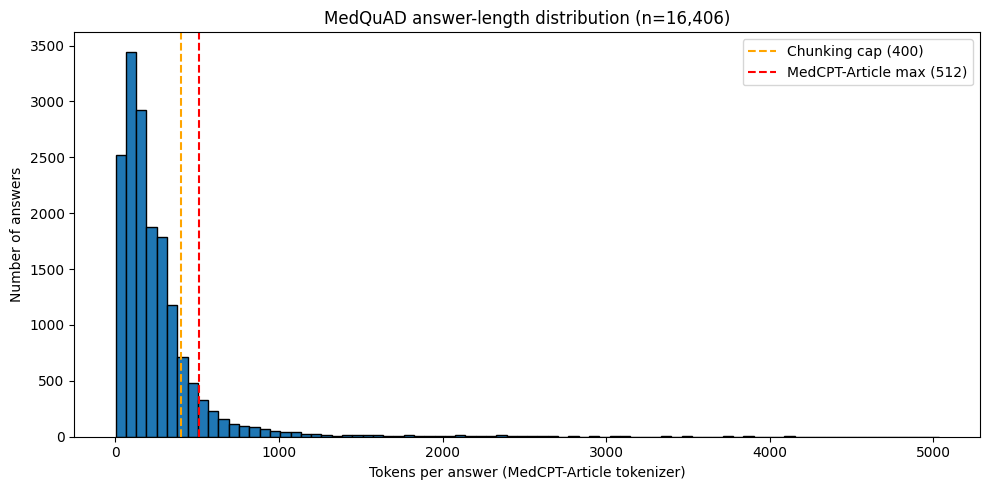

Median: 173 tokens
Mean: 249.5 tokens
95th percentile: 668 tokens
99th percentile: 1514 tokens
Max: 5033 tokens
% under 400: 85.3%
% 400-512: 5.9%
% over 512: 8.8%


In [66]:
import matplotlib.pyplot as plt

CHUNK_CAP = 400
MEDCPT_MAX = 512

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(token_counts, bins=80, edgecolor='black')
ax.axvline(CHUNK_CAP, color='orange', linestyle='--', label=f'Chunking cap ({CHUNK_CAP})')
ax.axvline(MEDCPT_MAX, color='red', linestyle='--', label=f'MedCPT-Article max ({MEDCPT_MAX})')
ax.set_xlabel('Tokens per answer (MedCPT-Article tokenizer)')
ax.set_ylabel('Number of answers')
ax.set_title('MedQuAD answer-length distribution (n=16,406)')
ax.legend()
fig.tight_layout()
plt.show()

tc = np.asarray(token_counts)
print(f"Median: {int(np.median(tc))} tokens")
print(f"Mean: {tc.mean():.1f} tokens")
print(f"95th percentile: {int(np.percentile(tc, 95))} tokens")
print(f"99th percentile: {int(np.percentile(tc, 99))} tokens")
print(f"Max: {int(tc.max())} tokens")
print(f"% under 400: {(tc < 400).mean() * 100:.1f}%")
print(f"% 400-512: {((tc >= 400) & (tc < 512)).mean() * 100:.1f}%")
print(f"% over 512: {(tc >= 512).mean() * 100:.1f}%")

## 3.3: Stratification check

I stratified the split on `question_type` in Section 2, but I never actually checked it worked. This cell builds a per-split proportion table and reports the largest gap between splits for each type. If stratification held, every gap should be under 1 percentage point.

In [67]:
# Verify stratification: each question type should appear in roughly
# the same proportion across the four splits.

corpus = load_from_disk(str(DATA_DIR / "medquad_corpus_source"))
train_pool = load_from_disk(str(DATA_DIR / "split_train_pool"))
val = load_from_disk(str(DATA_DIR / "split_val"))
test = load_from_disk(str(DATA_DIR / "split_test"))

type_names = corpus.features["question_type"].names

def proportions(split):
    s = pd.Series(split["question_type"]).value_counts(normalize=True) * 100
    s.index = [type_names[i] for i in s.index]
    return s

df = pd.DataFrame({
    "corpus": proportions(corpus),
    "train_pool": proportions(train_pool),
    "val": proportions(val),
    "test": proportions(test),
}).sort_values("corpus", ascending=False)

df["max_drift"] = df.max(axis=1) - df.min(axis=1)

print(df.round(2).to_string())
print(f"\nWorst-case drift across all classes: {df['max_drift'].max():.2f} pp")

                 corpus  train_pool    val   test  max_drift
information       27.64       27.64  27.67  27.61       0.06
symptoms          16.75       16.75  16.76  16.76       0.01
treatment         14.88       14.88  14.87  14.93       0.06
inheritance        8.81        8.82   8.84   8.78       0.06
frequency          6.83        6.83   6.83   6.83       0.00
genetic changes    6.63        6.62   6.64   6.64       0.02
causes             4.43        4.43   4.45   4.39       0.06
exams and tests    3.98        3.98   4.02   3.96       0.06
research           2.41        2.41   2.38   2.44       0.06
outlook            2.20        2.20   2.19   2.19       0.01
susceptibility     1.97        1.97   1.95   2.01       0.06
considerations     1.43        1.43   1.40   1.46       0.06
prevention         1.28        1.28   1.28   1.28       0.00
stages             0.47        0.47   0.49   0.43       0.06
complications      0.28        0.28   0.24   0.30       0.06

Worst-case drift across

## Section 3: Findings

- MedQuAD answer lengths are **heavily right-skewed**: median **173 tokens**, mean **249.5**, max **5,033**.
- **8.8%** of answers exceed MedCPT-Article's **512-token input ceiling** and would be silently truncated without chunking. That's what makes Section 4 necessary.
- Stratification held. **Worst-case drift across the four splits was 0.06 percentage points**, well under 1.
- Class imbalance is real and stratification doesn't fix it. `information` (**27.64%**) and `symptoms` (**16.75%**) make up nearly half the corpus, while `complications` (**0.28%**) and `stages` (**0.47%**) are each under 0.5%.
- With only **1,641 rows** in val/test, the rarest types end up with single-digit sample sizes (`complications` ≈ 5 rows, `stages` ≈ 7 rows), so per-type metrics for them will be unstable.

---

# Section 4: Chunking

Section 3.2 showed 8.8% of answers (~1,444 rows) exceed MedCPT-Article's 512-token input ceiling. Handed to MedCPT unchanged, those rows would be silently truncated. This section splits every corpus answer into pieces that fit under the ceiling.

I cap chunks at 400 MedCPT-Article tokens with 50 tokens of overlap between adjacent chunks from the same answer. Each chunk carries its text, the index of its source row in `corpus`, and that row's `question_type`. The source-row index is what Section 7 uses to map a retrieved chunk back to its original answer.

Section 4.3 plots the post-chunking length distribution to confirm the cap held.

## 4.1: Configure the splitter

`RecursiveCharacterTextSplitter` measures chunk size in characters by default. With `chunk_size=400` and `chunk_overlap=50` as written, those numbers would mean 400 characters and 50-character overlap. I want the unit to be MedCPT tokens instead, so I pass `length_function=medcpt_token_len`. That function counts MedCPT tokens with `add_special_tokens=False` (same convention as 3.2), so the 400-token cap here matches what the encoder sees in Section 5.

Sanity-check on a short test paragraph first. The cell asserts every produced chunk is ≤400 tokens; if the config is wrong, the kernel fails here instead of silently producing oversized chunks across 16,406 answers in 4.2.

In [68]:
from langchain_text_splitters import RecursiveCharacterTextSplitter # Reminder: Mention in the report why I used langchain_text_splitters instead of Hugging Face.

CHUNK_SIZE = 400 # Max chunk size in MedCPT-Article tokens.
CHUNK_OVERLAP = 50 # Tokens shared between adjacent chunks to preserve cross-boundary context.

# 1. Tokenize the text and return the count, not the tokens.
#    The splitter only needs a length to compare against the 400 cap.
def medcpt_token_len(text: str) -> int: 
    return len(tokenizer.encode(text, add_special_tokens=False))

# 2. Build the splitter.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=medcpt_token_len,
)

# Sanity check on a short paragraph.
test_text = (
    "Diabetes is a metabolic disease.\n\n"
    "People with type 2 diabetes have insulin resistance. Their bodies do not "
    "use insulin properly, so glucose builds up in the blood instead of being "
    "absorbed by cells.\n\n"
    "Treatment includes diet, exercise, and medication."
)
chunks = splitter.split_text(test_text) # Chop test_text into chunks.
chunk_lens = [medcpt_token_len(c) for c in chunks] # Measure each chunk's length in tokens.

print(f"Test text:\n  Total chunks: {len(chunks)}\n  Lengths: {chunk_lens} tokens (cap={CHUNK_SIZE})")

assert max(chunk_lens) <= CHUNK_SIZE # Crash here if any chunk exceeds the cap.
print("✅ test_text chunks are within the chunk size limit.")

Test text:
  Total chunks: 1
  Lengths: [46] tokens (cap=400)
✅ test_text chunks are within the chunk size limit.


## 4.2: Chunk all 16,406 corpus answers

Apply the splitter to every answer in `corpus`. For each chunk it produces, store the chunk text plus its source row index and question type. The source row is the breadcrumb Section 7 uses to map a retrieved chunk back to its original answer; the question type is duplicated from the source row so eval analysis in Section 8 can group chunks by category without a corpus lookup per chunk.

The cell re-asserts the 400-token cap over the full corpus and saves the result to `DATA_DIR / "medquad_chunks"` so Section 5 reads from disk on a kernel restart instead of re-chunking.

The output is `chunks_ds`, expected to grow beyond 16,406 rows because answers over 400 tokens each contribute multiple chunks.

In [69]:
from datasets import Dataset

chunk_texts, source_rows, question_types = [], [], []  # source_rows traces a chunk back to corpus; question_type is duplicated for per-class analysis in Section 8.5 / 9.1.
for i, row in enumerate(corpus):
    for chunk in splitter.split_text(row["answer"]):
        chunk_texts.append(chunk)
        source_rows.append(i)
        question_types.append(row["question_type"])

chunks_ds = Dataset.from_dict({
    "chunk_text": chunk_texts,
    "source_row": source_rows,
    "question_type": question_types,
})

chunk_lens = [medcpt_token_len(c) for c in chunk_texts]
assert max(chunk_lens) <= CHUNK_SIZE

chunks_ds.save_to_disk(str(DATA_DIR / "medquad_chunks"))
print(f"{len(chunks_ds):,} chunks, max length {max(chunk_lens)} tokens")

20,604 chunks, max length 400 tokens


## 4.3: Post-chunking length distribution

The splitter ran without crashing, which means no chunk exceeded 400 tokens (the assert in 4.2 would have stopped the kernel). I still want to see the distribution: how many chunks landed near the 400 cap, and what the long tail of short chunks looks like.

Histogram of every chunk's MedCPT-Article token count, with a reference line at 400. Section 3.2 plotted the input to this section (whole-answer lengths); this plots the output.

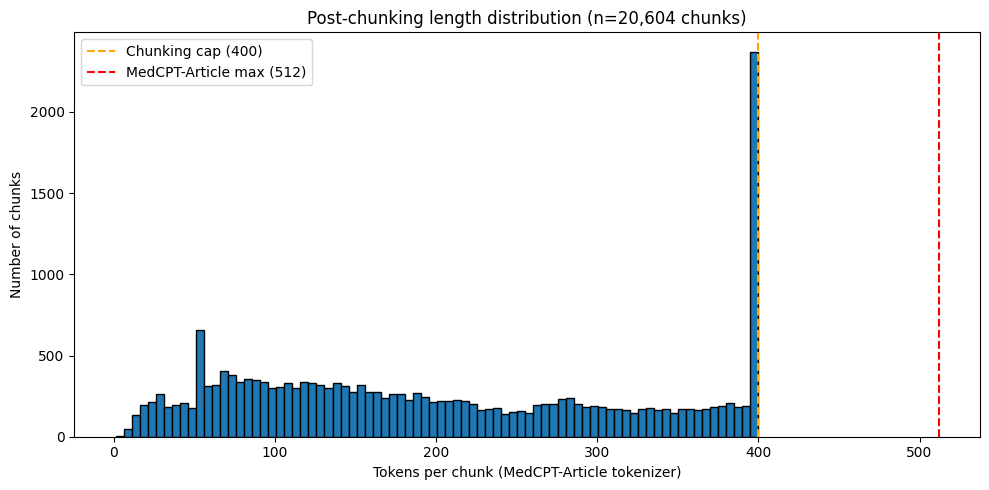

Median: 184 tokens
Mean: 205.1 tokens
Min: 1 tokens
Max: 400 tokens
95th percentile: 400 tokens
99th percentile: 400 tokens
% chunks under 200: 53.7%
% chunks at exactly cap: 8.6%


In [70]:
import matplotlib.pyplot as plt

MEDCPT_MAX = 512

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(chunk_lens, bins=80, edgecolor='black')
ax.axvline(CHUNK_SIZE, color='orange', linestyle='--', label=f'Chunking cap ({CHUNK_SIZE})')
ax.axvline(MEDCPT_MAX, color='red', linestyle='--', label=f'MedCPT-Article max ({MEDCPT_MAX})')
ax.set_xlabel('Tokens per chunk (MedCPT-Article tokenizer)')
ax.set_ylabel('Number of chunks')
ax.set_title(f'Post-chunking length distribution (n={len(chunk_lens):,} chunks)')
ax.legend()
fig.tight_layout()
plt.show()

cl = np.asarray(chunk_lens)
print(f"Median: {int(np.median(cl))} tokens")
print(f"Mean: {cl.mean():.1f} tokens")
print(f"Min: {int(cl.min())} tokens")
print(f"Max: {int(cl.max())} tokens")
print(f"95th percentile: {int(np.percentile(cl, 95))} tokens")
print(f"99th percentile: {int(np.percentile(cl, 99))} tokens")
print(f"% chunks under 200: {(cl < 200).mean() * 100:.1f}%")
print(f"% chunks at exactly cap: {(cl == CHUNK_SIZE).mean() * 100:.1f}%")

### Verifying chunk-distribution claims

The Section 4 Findings cell makes three claims about the chunk distribution: how many answers stayed as a single chunk, how many split into 2 or more, and the longest split. This cell computes all three from `chunks_ds["source_row"]` so the figures in Findings come from a printed output.

In [71]:
chunks_per_row = Counter(chunks_ds["source_row"])
max_chunks = max(chunks_per_row.values())
longest_row = max(chunks_per_row, key=chunks_per_row.get)

n_answers = len(chunks_per_row)
n_single = sum(1 for c in chunks_per_row.values() if c == 1)
n_multi = n_answers - n_single
pct_single = 100 * n_single / n_answers
pct_multi = 100 * n_multi / n_answers

print(f"Longest answer was split into {max_chunks} chunks")
print(f"  (source_row index = {longest_row})")
print(f"Single-chunk answers: {n_single:,} of {n_answers:,} ({pct_single:.1f}%)")
print(f"Split into 2+ chunks: {n_multi:,} of {n_answers:,} ({pct_multi:.1f}%)")

Longest answer was split into 16 chunks
  (source_row index = 12472)
Single-chunk answers: 14,000 of 16,406 (85.3%)
Split into 2+ chunks: 2,406 of 16,406 (14.7%)


## Section 4: Findings

- Chunking turned **16,406 answers** into **20,604 chunks** (**1.26× expansion**).
- **85.3%** of answers stayed as a single chunk; **14.7%** split into 2 or more.
- Longest answer produced **16 chunks**.
- The cap held: every chunk is **≤400 MedCPT-Article tokens**, leaving **110 tokens of headroom** under MedCPT's 512-token ceiling once `[CLS]` and `[SEP]` are added.
- Distribution is right-skewed: **median 184 tokens**, **53.7% under 200 tokens**, **8.6% sit at exactly the 400 cap**.

The pile at 400 is the long tail of answers where the splitter exhausted its natural separators (`\n\n`, `\n`, space) and fell back to a hard cut.

---

# Section 5: Embedding

Convert each of the 20,604 chunks into a 768-dim float32 vector using `ncbi/MedCPT-Article-Encoder`, with [CLS] pooling and L2-normalization, then save to disk for FAISS to index in Section 6.

MedCPT is a bi-encoder: queries and articles are encoded by two separate networks, trained jointly so their output vectors share one 768-dim space. This section uses only the article encoder; the query encoder comes online in Section 7 when there's a user question to embed.

Three load-bearing decisions in this section, each of which can silently produce wrong vectors if skipped:

- **[CLS] pooling**, not mean pooling: `output.last_hidden_state[:, 0, :]`. The model card example and the MedCPT paper (Jin et al., Bioinformatics 2023) both use this. Mean pooling produces wrong vectors with no error.
- **L2-normalize after slicing**, so dot product equals cosine similarity. FAISS `IndexFlatIP` (Section 6) assumes pre-normalized vectors.
- **`attn_implementation="sdpa"`**, because flash-attention has no aarch64 wheel for the GB10.

## 5.1: Load the MedCPT-Article encoder

Load `ncbi/MedCPT-Article-Encoder` from the HuggingFace Hub, move it to `DEVICE`, and switch to eval mode. The first download caches the weights locally; subsequent runs read from cache. The model has 109.5M parameters at float32, occupying about 440 MB on disk.

`.eval()` disables dropout. The MedCPT model card's example skips this step, but without it the BERT dropout layers stay active during inference and re-runs would produce slightly different embeddings.

In [72]:
import torch # For inference_mode and tensor ops in cell 45.
from transformers import AutoModel

# AutoModel inspects the pretrained model's config.json to find the architecture
# class and downloads the matching weights. For ncbi/MedCPT-Article-Encoder it
# returns a BertModel; we don't have to know that explicitly.
article_encoder = AutoModel.from_pretrained(
    "ncbi/MedCPT-Article-Encoder",
    attn_implementation="sdpa", # flash-attn unavailable on aarch64
)
article_encoder = article_encoder.to(DEVICE).eval() # Switch to eval mode (disables dropout etc).

n_params = sum(p.numel() for p in article_encoder.parameters())
print("Loaded ncbi/MedCPT-Article-Encoder")
print(f"Parameters: {n_params/1e6:.1f}M")
print(f"Device: {next(article_encoder.parameters()).device}")
print(f"Dtype: {next(article_encoder.parameters()).dtype}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded ncbi/MedCPT-Article-Encoder
Parameters: 109.5M
Device: cuda:0
Dtype: torch.float32


## 5.2: Embed all 20,604 chunks

The per-batch pipeline:

1. Tokenize a batch of 64 chunks with padding and truncation at `max_length=512`.
2. Run the batch through the article encoder under `torch.inference_mode()`.
3. Slice the `[CLS]` vector from each output: `output.last_hidden_state[:, 0, :]`.
4. L2-normalize each vector so the dot product against any other normalized vector equals their cosine similarity.
5. Move to CPU and accumulate.

After all batches finish, stack into a `(20604, 768)` float32 array and save as `embeddings.npy`.

`max_length=512` matches MedCPT-Article's input ceiling. In practice no chunk hits 512 because Section 4 capped them at 400 tokens, but the safety net stays cheap.

I keep the encoder at FP32 rather than BF16 for run-to-run reproducibility on the GB10's Blackwell GPU. The embeddings will be compared in Section 6's FAISS index, where any drift in vector values would change retrieval results.

In [73]:
import torch.nn.functional as F

# Convert the chunk_text column in chunks_ds into a Python list for batched indexing below.
chunk_texts = list(chunks_ds["chunk_text"])
print(f"Embedding {len(chunk_texts):,} chunks...")

BATCH_SIZE = 64
all_embeddings = []

with torch.inference_mode():  # Skip gradient tracking and version-counter updates; faster than no_grad.
    for start in range(0, len(chunk_texts), BATCH_SIZE): # Step through all chunks in 64-row windows.
        batch = chunk_texts[start:start + BATCH_SIZE]  # First iteration: indices 0 to 63.
        enc = tokenizer(  # Tokenize the batch in one call.
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt", # Return PyTorch tensors instead of Python lists.
        ).to(DEVICE)

        out = article_encoder(**enc)  # Forward pass on the batch.

        # [CLS] pooling: take the first token's hidden state. NOT mean.
        cls_vecs = out.last_hidden_state[:, 0, :]      # (B, 768)
        # L2-normalize so dot product == cosine similarity.
        cls_vecs = F.normalize(cls_vecs, p=2, dim=1)   # (B, 768)

        all_embeddings.append(cls_vecs.cpu())

embeddings = torch.cat(all_embeddings, dim=0).numpy()  # (N, 768) float32

# Sanity checks.
assert embeddings.shape == (len(chunks_ds), 768), embeddings.shape
norms = np.linalg.norm(embeddings, axis=1)
assert np.allclose(norms, 1.0, atol=1e-5), f"L2-norms not unit: {norms[:5]}"

np.save(DATA_DIR / "embeddings.npy", embeddings)

print(f"Shape: {embeddings.shape}, dtype: {embeddings.dtype}")
print(f"Mean L2-norm: {norms.mean():.6f} (expect 1.000000)")
print(f"Saved to {DATA_DIR / 'embeddings.npy'} ({embeddings.nbytes / 1e6:.1f} MB)")

Embedding 20,604 chunks...
Shape: (20604, 768), dtype: float32
Mean L2-norm: 1.000000 (expect 1.000000)
Saved to /home/alex/Projects/Aletheia/data/embeddings.npy (63.3 MB)


## 5.3: Sanity-check the embeddings

Run four asserts on the `embeddings` array before Section 6 hands it to FAISS. Any of these silently failing in Section 5.2 would survive into retrieval and corrupt every downstream result.

1. **Shape** is `(len(chunks_ds), 768)`. Catches a wrong row count or wrong dimension.
2. **Dtype** is `float32`. Catches a silent BF16 or FP16 downcast that would break determinism.
3. **L2-norms are 1.0 ± 1e-5** on every row. Catches a missing `F.normalize` or wrong axis on the normalization.
4. **Round-trip cosine ≈ 1.0** on chunk 0: re-encode it fresh and compare to its stored vector. Catches a non-deterministic encoder, which would mean retrieval results aren't reproducible.

If all four pass, `embeddings.npy` is safe to use.

In [74]:
# Section 5.3: sanity checks before FAISS.

# 1. Shape.
assert embeddings.shape == (len(chunks_ds), 768), \
    f"Bad shape {embeddings.shape}, expected ({len(chunks_ds)}, 768)"

# 2. Dtype.
assert embeddings.dtype == np.float32, f"Bad dtype {embeddings.dtype}, expected float32"

# 3. Unit norms.
norms = np.linalg.norm(embeddings, axis=1)
assert norms.min() > 1 - 1e-5 and norms.max() < 1 + 1e-5, \
    f"L2-norms not unit. min={norms.min()}, max={norms.max()}"

# 4. Round-trip: re-embed chunk 0, compare cosine similarity to stored vector.
sample_text = chunks_ds[0]["chunk_text"]
with torch.inference_mode():
    enc = tokenizer(sample_text, truncation=True,
                    max_length=512, return_tensors="pt").to(DEVICE)
    out = article_encoder(**enc)
    cls = F.normalize(out.last_hidden_state[:, 0, :], p=2, dim=1)
    fresh = cls.cpu().numpy()[0]

cos = float(np.dot(fresh, embeddings[0]))
assert abs(cos - 1.0) < 1e-5, \
    f"Round-trip cosine = {cos}, expected 1.0 (encoder may not be deterministic)"

print("All four sanity checks passed.")
print(f"  shape: {embeddings.shape}")
print(f"  dtype: {embeddings.dtype}")
print(f"  unit norms: (min={norms.min():.6f}, max={norms.max():.6f})")
print(f"  round-trip: (cos={cos:.6f})")

All four sanity checks passed.
  shape: (20604, 768)
  dtype: float32
  unit norms: (min=1.000000, max=1.000000)
  round-trip: (cos=1.000000)


---

# Section 6: FAISS index

Build a `faiss.IndexFlatIP` over the 20,604 embeddings. Exact brute-force inner-product search at 20K × 768 dimensions runs fast enough on the GB10 that approximate-nearest-neighbor (ANN) methods like HNSW or IVF aren't worth the added hyperparameter tuning for this corpus size.

Because the embeddings are L2-normalized in 5.2, inner product equals cosine similarity. No separate `IndexFlatL2` and no in-FAISS normalization step.

I ship `embeddings.npy` rather than `index.faiss` because FAISS index files aren't binary-compatible across CPU architectures: the GB10 is aarch64 while most graders' machines are x86_64, and FAISS index serialization depends on the build target. Shipping the raw embeddings lets a grader rebuild the index on any machine with `faiss-cpu` installed.

## 6.1: Build and populate the index

Create the index and add the embeddings. Three lines of FAISS plus an assert that verifies every row landed in the index.


In [75]:
import faiss

EMBED_DIM = 768
index = faiss.IndexFlatIP(EMBED_DIM)
index.add(embeddings)

assert index.ntotal == len(embeddings), \
    f"Index has {index.ntotal} vectors, expected {len(embeddings)}"

print(f"Built faiss.IndexFlatIP(d={EMBED_DIM})")
print(f"Vectors indexed: {index.ntotal:,}")

Built faiss.IndexFlatIP(d=768)
Vectors indexed: 20,604


## 6.2: Smoke-test the index

Confirm the index returns sensible neighbors before Section 7 trusts it. The cell runs a self-query: search for chunk 0's stored vector in the index. Since chunk 0 is in the index, it should come back at rank 1 with similarity ≈ 1.0.

Two asserts run on the rank-1 result:

1. The rank-1 index is 0. Catches embeddings loaded in the wrong row order.
2. The rank-1 similarity is within `1e-5` of 1.0. Catches a wrong distance metric (e.g., `IndexFlatL2` instead of `IndexFlatIP`) or unnormalized vectors slipping through 5.3.

Ranks 2 through 5 are printed for inspection, not asserted. They should be distinct chunks with similarity values declining below 1.0.

In [76]:
# Search for chunk 0's nearest 5 neighbors.
D, I = index.search(embeddings[0:1], 5)   # D = similarities, I = chunk indices

assert I[0, 0] == 0, f"Rank-1 should be chunk 0 itself, got {I[0, 0]}"
assert abs(D[0, 0] - 1.0) < 1e-5, f"Self-similarity should be 1.0, got {D[0, 0]}"

print(f"Query: chunks_ds[0]")
print(f"  source_row = {chunks_ds[0]['source_row']}")
print(f"  question_type = {chunks_ds[0]['question_type']}")
print(f"  text (first 100 chars) = {chunks_ds[0]['chunk_text'][:100]!r}")
print()
print(f"Top-5 neighbors:")
for rank, (sim, idx) in enumerate(zip(D[0], I[0]), start=1):
    qt = chunks_ds[int(idx)]["question_type"]
    print(f"  rank {rank}: chunk {idx} (sim={sim:.4f}, qtype={qt})")

Query: chunks_ds[0]
  source_row = 0
  question_type = 6
  text (first 100 chars) = 'Keratoderma with woolly hair is a group of related conditions that affect the skin and hair and in m'

Top-5 neighbors:
  rank 1: chunk 0 (sim=1.0000, qtype=6)
  rank 2: chunk 1 (sim=0.8355, qtype=4)
  rank 3: chunk 5341 (sim=0.8241, qtype=6)
  rank 4: chunk 5552 (sim=0.8233, qtype=6)
  rank 5: chunk 4 (sim=0.8174, qtype=14)


---

# Section 7: Retrieval and generation

End-to-end RAG (Retrieval-Augmented Generation):

1. Take a user question.
2. Encode it with `MedCPT-Query-Encoder`.
3. Retrieve the top-3 most similar chunks from the FAISS index.
4. Reorder them with the lost-in-the-middle (LITM) heuristic.
5. Splice them into a prompt.
6. Generate an answer with `BioMistral/BioMistral-7B-SLERP` under greedy decoding.

I use top-k = 3 rather than larger values primarily to limit exposure to the lost-in-the-middle effect: the LITM reorder helps but doesn't eliminate it, and the effect compounds with more context. The context budget is not a constraint here. Three 400-token chunks plus the prompt template plus a 256-token generation budget fit well within BioMistral's 32,768-token context window (`max_position_embeddings`), which Section 7.6 enforces at runtime via the `CTX_LIMIT` check. BioMistral inherits Mistral-7B-v0.1's 4,096-token sliding-window attention, so each attention layer only reaches back 4,096 tokens regardless of input length. At these prompt sizes the distinction is moot, but it matters for tasks placing key information thousands of tokens apart.

LITM reorder follows Liu et al. (TACL 2024): decoder-only language models use information at the start and end of their context better than information in the middle. I place rank-1 at the end (closest to the question, the most "active" position), rank-2 at the start, and rank-3 in the middle. The retrieval results don't change; only the ordering in the prompt does.

## 7.1: Load the MedCPT-Query encoder

Load `ncbi/MedCPT-Query-Encoder` and its matching tokenizer. The query encoder is a separate BERT-family model from the article encoder loaded in 5.1. Both have 109.5M parameters and produce 768-dim vectors. They were trained jointly on 255M query-article pairs from PubMed search logs, so their output vectors live in the same embedding space: a query vector lands close to vectors for articles that answer it.

The query tokenizer shares its vocabulary with the article tokenizer (both were initialized from PubMedBERT). I load it separately to keep the query encoding path syntactically symmetric with the article encoding path.

Queries are tokenized with `max_length=64`. That's the convention from the MedCPT model card's official example; queries longer than 64 tokens are truncated.

In [77]:
# Same AutoModel dispatch as cell 43, this time for the query encoder.
query_encoder = AutoModel.from_pretrained(
    "ncbi/MedCPT-Query-Encoder",
    attn_implementation="sdpa", # flash-attn unavailable on aarch64
)
query_encoder = query_encoder.to(DEVICE).eval()

query_tokenizer = AutoTokenizer.from_pretrained("ncbi/MedCPT-Query-Encoder")

n_params = sum(p.numel() for p in query_encoder.parameters())
print("Loaded ncbi/MedCPT-Query-Encoder")
print(f"Parameters: {n_params/1e6:.1f}M")
print(f"Device: {next(query_encoder.parameters()).device}")
print(f"Dtype: {next(query_encoder.parameters()).dtype}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded ncbi/MedCPT-Query-Encoder
Parameters: 109.5M
Device: cuda:0
Dtype: torch.float32


## 7.2: Encode a query and retrieve top-k chunks

Wrap query encoding and FAISS search in one function `retrieve(question, k)` so Section 7.7 can call it. The per-query pipeline:

1. Tokenize the question with `max_length=64` (the MedCPT-Query convention).
2. Forward-pass through the query encoder under `inference_mode()`.
3. Take the `[CLS]` vector.
4. L2-normalize it.
5. Hand the resulting 768-dim unit vector to `index.search` for top-k retrieval.

A demo at the bottom calls `retrieve` with a sample diabetes question and prints the source row, question type, and a short text preview for each of the top-3 results.

In [78]:
TOP_K = 3

def retrieve(question: str, k: int = TOP_K):
    """Encode a question with MedCPT-Query and return top-k FAISS hits."""
    with torch.inference_mode():
        enc = query_tokenizer(
            question,
            truncation=True,
            max_length=64,
            return_tensors="pt",
        ).to(DEVICE)
        out = query_encoder(**enc)
        qvec = F.normalize(out.last_hidden_state[:, 0, :], p=2, dim=1)
        qvec = qvec.cpu().numpy()

    D, I = index.search(qvec, k)
    return D[0], I[0]

# Demo.
demo_q = "What are the symptoms of type 2 diabetes?"
sims, idxs = retrieve(demo_q, k=TOP_K)

print(f"Query: {demo_q}\nTop-{TOP_K} chunks:")
for rank, (s, i) in enumerate(zip(sims, idxs), start=1):
    r = chunks_ds[int(i)]
    print(f"  rank {rank}: sim={s:.4f}, source_row={r['source_row']}, qtype={r['question_type']}")
    print(f"    text: {r['chunk_text'][:120]!r}...")

Query: What are the symptoms of type 2 diabetes?
Top-3 chunks:
  rank 1: sim=0.6704, source_row=16222, qtype=13
    text: 'The signs and symptoms of type 2 diabetes can be so mild that you might not even notice them. Nearly 7 million people in'...
  rank 2: sim=0.6696, source_row=16130, qtype=6
    text: 'Other Types of Diabetes\n                \nMany other types of diabetes exist, and a person can exhibit characteristics of'...
  rank 3: sim=0.6686, source_row=15971, qtype=6
    text: 'Insulin resistance is a condition in which the body produces insulin but does not use it effectively. When people have i'...


## 7.3: Lost-in-the-middle reorder

Given chunks ordered by descending similarity, reorder them by position in the prompt:

1. Most-similar chunk goes at the end (just before the question).
2. Second-most-similar goes at the start.
3. The rest fill the middle.

The reasoning is that decoder-only language models attend more strongly to the start and end of their context. Placing the most-relevant chunk where attention is highest improves answer quality at no extra cost.

Concrete results of the rule:

- `k=1`: `[rank-1]` (nothing to reorder).
- `k=2`: `[rank-2, rank-1]`.
- `k=3`: `[rank-2, rank-3, rank-1]`.

In [79]:
def litm_reorder(chunks_in_descending_similarity):
    """Reorder chunks for lost-in-the-middle mitigation.

    Most-similar at end, second-most at start, rest in middle.
    For k=3: [rank2, rank3, rank1]
    """
    cs = list(chunks_in_descending_similarity)
    if len(cs) <= 1:
        return cs
    most_similar = cs[0]
    second = cs[1]
    middle = cs[2:]
    return [second] + middle + [most_similar]

# Demo: show how the order changes for the demo question above.
ordered_chunks = [chunks_ds[int(i)] for i in idxs]
litm = litm_reorder(ordered_chunks)
print("LITM-reordered chunk source_rows (k=3):")
print(f"  before: {[c['source_row'] for c in ordered_chunks]} (rank 1, 2, 3)")
print(f"  after: {[c['source_row'] for c in litm]} (rank 2, 3, 1)")

LITM-reordered chunk source_rows (k=3):
  before: [16222, 16130, 15971] (rank 1, 2, 3)
  after: [16130, 15971, 16222] (rank 2, 3, 1)


## 7.4: Build the prompt

`build_prompt(question, chunks)` returns one string in this layout:

```
You are a medical expert. Answer the question using only the context below.
If the context does not contain the answer, say "I do not know."

Context:
[chunk 1 text]

[chunk 2 text]

[chunk 3 text]

Question: {question}
Answer:
```

Plain instruction format, not Mistral's chat template. `BioMistral-7B-SLERP` is a SLERP merge of `Mistral-7B-Instruct-v0.1` and `BioMistral-7B` (which was itself pre-trained from `Mistral-7B-Instruct-v0.1` on PubMed Central). The model card and the original BioMistral evaluations use plain prompt formats for QA tasks rather than chat templates, so I follow that convention for the comparison to land cleanly.

The `"I do not know"` refusal instruction is the abstain fallback: it gives BioMistral a permitted response when none of the retrieved chunks contain the answer, instead of forcing it to hallucinate.


In [80]:
PROMPT_TEMPLATE = (
    "You are a medical expert. Answer the question using only the context below. "
    "If the context does not contain the answer, say \"I do not know.\"\n\n"
    "Context:\n{context}\n\n"
    "Question: {question}\n"
    "Answer:"
)

def build_prompt(question: str, chunks: list) -> str:
    context = "\n\n".join(c["chunk_text"] for c in chunks)
    return PROMPT_TEMPLATE.format(context=context, question=question)

demo_prompt = build_prompt(demo_q, litm)
print(demo_prompt[:800] + ("..." if len(demo_prompt) > 800 else ""))
print(f"\nPrompt length (characters): {len(demo_prompt):,}")


You are a medical expert. Answer the question using only the context below. If the context does not contain the answer, say "I do not know."

Context:
Other Types of Diabetes
                
Many other types of diabetes exist, and a person can exhibit characteristics of more than one type. For example, in latent autoimmune diabetes in adults, people show signs of both type 1 and type 2 diabetes. Other types of diabetes include those caused by genetic defects, diseases of the pancreas, excess amounts of certain hormones resulting from some medical conditions, medications that reduce insulin action, chemicals that destroy beta cells, infections, rare autoimmune disorders, and genetic syndromes associated with diabetes.
                
More information about other types of diabetes is provi...

Prompt length (characters): 2,507


## 7.5: Load BioMistral-7B-SLERP

Load `BioMistral/BioMistral-7B-SLERP` at BF16 with `attn_implementation="sdpa"`, move to GPU, set to eval mode, and load the matching tokenizer. The weights are 14.48 GB on disk (two safetensors shards of 9.94 GB + 4.54 GB), which fits comfortably in the GB10's 128 GB unified memory.

The first run downloads the full weights from the Hub. Once cached, subsequent runs reuse the local copy and load in seconds.

After loading the tokenizer, set `pad_token_id = eos_token_id` if it's missing. Mistral's tokenizer doesn't define a pad token by default, but batched generation needs one. Reusing the EOS token for padding is the conventional fix.

In [81]:
# Section 7.5: load BioMistral-7B-SLERP.

from transformers import AutoModelForCausalLM

BIOMISTRAL_DTYPE = torch.bfloat16

gen_model = AutoModelForCausalLM.from_pretrained(
    "BioMistral/BioMistral-7B-SLERP",
    dtype=BIOMISTRAL_DTYPE,
    attn_implementation="sdpa",
).to(DEVICE).eval()

gen_tokenizer = AutoTokenizer.from_pretrained("BioMistral/BioMistral-7B-SLERP")
if gen_tokenizer.pad_token_id is None:
    gen_tokenizer.pad_token_id = gen_tokenizer.eos_token_id

n_params = sum(p.numel() for p in gen_model.parameters())
print("Loaded BioMistral/BioMistral-7B-SLERP")
print(f"Parameters: {n_params/1e9:.2f}B")
print(f"Dtype: {next(gen_model.parameters()).dtype}")
print(f"Device: {next(gen_model.parameters()).device}")
print(f"Context window: {gen_model.config.max_position_embeddings} tokens")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded BioMistral/BioMistral-7B-SLERP
Parameters: 7.24B
Dtype: torch.bfloat16
Device: cuda:0
Context window: 32768 tokens


## 7.6: Generation function (greedy, deterministic)

`generate_answer(prompt)` runs the prompt through BioMistral with greedy decoding and returns just the generated continuation. The prompt tokens are sliced off before decoding, so the output is purely the model's new text. Greedy decoding is fully deterministic given the same prompt and same model state, which is what's needed for reproducible eval.

Two decoding-setting choices:

1. `do_sample=False` rather than `temperature=0`. Modern transformers raises a `ValueError` on `temperature=0`, and the HuggingFace docs direct users to `do_sample=False` for greedy decoding. The two are not interchangeable.
2. `pad_token_id=gen_tokenizer.eos_token_id`. Mistral's tokenizer has no default pad token; passing `eos_token_id` here silences a benign HF warning during generation.

Before generating, the function asserts `n_prompt + MAX_NEW_TOKENS ≤ CTX_LIMIT` and raises a clear error otherwise. This prevents the generator from running past the context window on an unexpectedly long prompt.

In [82]:
MAX_NEW_TOKENS = 256
CTX_LIMIT = gen_model.config.max_position_embeddings

def generate_answer(prompt: str) -> str:
    enc = gen_tokenizer(prompt, return_tensors="pt").to(DEVICE)
    n_prompt = enc["input_ids"].shape[1]

    if n_prompt + MAX_NEW_TOKENS > CTX_LIMIT:
        raise ValueError(
            f"Prompt is {n_prompt} tokens; with {MAX_NEW_TOKENS} max_new_tokens "
            f"this exceeds the {CTX_LIMIT}-token window."
        )

    with torch.inference_mode():
        out = gen_model.generate(
            **enc,
            do_sample=False, # Greedy decoding.
            num_beams=1,   # Disable beam search; combined with do_sample=False, this is strict greedy.
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=gen_tokenizer.eos_token_id,
        )

    new_tokens = out[0, n_prompt:]
    return gen_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

demo_answer = generate_answer(demo_prompt)
print(f"Question: {demo_q}\n")
print(f"Generated answer:\n{demo_answer}")

Question: What are the symptoms of type 2 diabetes?

Generated answer:
Increased thirst, increased hunger, fatigue, increased urination, especially at night, unexplained weight loss, blurred vision, numbness or tingling in the feet or hands, sores that do not heal.


## 7.7: End-to-end QA function

`answer_question(question, k=3)` wraps the four Section 7 helpers (`retrieve`, `litm_reorder`, `build_prompt`, `generate_answer`) into one callable. It returns the generated answer string and the list of retrieved chunk indices. Section 8.3 stores both per test question so the eval can trace each answer back to the chunks that produced it.

In [83]:
# Section 7.7: end-to-end RAG QA function.

def answer_question(question: str, k: int = TOP_K):
    sims, idxs = retrieve(question, k=k)
    chunks = [chunks_ds[int(i)] for i in idxs]
    ordered = litm_reorder(chunks)
    prompt = build_prompt(question, ordered)
    answer = generate_answer(prompt)
    return answer, [int(x) for x in idxs]

# Demo.
ans, retrieved = answer_question(demo_q)
print(f"Q: {demo_q}\n")
print(f"Retrieved chunk indices: {retrieved}")
print(f"\nA: {ans}")

Q: What are the symptoms of type 2 diabetes?

Retrieved chunk indices: [20312, 20175, 19948]

A: Increased thirst, increased hunger, fatigue, increased urination, especially at night, unexplained weight loss, blurred vision, numbness or tingling in the feet or hands, sores that do not heal.


---

# Section 8: Evaluation

Two metric families on the held-out test split.

For retrieval (per-question): Top-k Accuracy at k = 1, 3, 5 checks whether any gold chunk appears in the top-k retrieved. With one gold doc per query (each test question maps to one source row in the corpus, identified by the composite key built in 8.1), Recall@k collapses to Top-k Accuracy. I label it Top-k Accuracy in the report so the discussion stays honest. MRR@5 and MRR@10 measure the rank of the first gold chunk found, capped at the cutoff.

For generation (per-question, generated vs gold answer): ROUGE-L F1 measures longest-common-subsequence overlap (surface lexical), and BERTScore F1 measures contextual-embedding similarity (default RoBERTa-large with `rescale_with_baseline=True`).

Important caveat for the report's Limitations section: traditional automatic metrics like ROUGE-L and BERTScore are known to correlate weakly with expert factual judgments on medical text. The MORQA benchmark (Yim et al., arxiv:2509.12405, 2025) demonstrates that LLM-based evaluators significantly outperform traditional metrics like BERTScore in correlating with expert human judgments on medical open-ended QA. ROUGE-L and BERTScore measure surface and semantic similarity, not clinical correctness. The metrics chosen here are the offline-reproducible compromise the rubric rewards.

Compute budget: 1,641 questions × ~3-5 sec end-to-end ≈ 80-140 minutes on the GB10. If time-tight, eval a 500-question subsample first; full sweep last.

## 8.1: Build the test-split to gold-chunk mapping

For retrieval evaluation I need: given a test question, which chunks count as "the gold answer"? The path: a test question maps to one row in the original `corpus`, and that corpus row maps to one or more chunks (whichever chunks have `source_row` pointing back to it). Those chunks are the gold set for that question.

The trick is identifying which corpus row a test question came from. `question_id` looks like the obvious key, but it isn't unique. MedQuAD uses it as a *template* id (e.g., "0000559-1" = "first question template, variant 1"), and the same template appears across many different focuses. The same `question_id` covers things like keratoderma, Charcot-Marie-Tooth disease, and Listeria infections, three completely unrelated conditions sharing one qid. `(question_id, document_id)` isn't unique either. The composite `(question_id, document_id, question_focus)` is unique, verified by an assert below that catches collisions before they corrupt the metrics.

Once I have a unique row index per test question, the rest is mechanical: collect every chunk index where `source_row == that_corpus_index`. Most rows produce one gold chunk (85.3% per Section 4); long answers split into multiple. Retrieval is "correct" if any gold chunk lands in top-k.

In [84]:
# Section 8.1: map each test question to its gold chunk indices.

test = load_from_disk(str(DATA_DIR / "split_test"))
print(f"Test split: {len(test):,} rows")

# Build (question_id, document_id, question_focus) -> corpus row index lookup.
# question_id alone is NOT unique in MedQuAD (it's a template id, not a row id).
# (qid, did) is also NOT unique. The composite (qid, did, focus) uniquely
# identifies each of the 16,406 rows. The assert below proves this.
corpus_qid_to_idx = {
    (q, d, f): i
    for i, (q, d, f) in enumerate(zip(
        corpus["question_id"], corpus["document_id"], corpus["question_focus"]
    ))
}
assert len(corpus_qid_to_idx) == len(corpus), (
    f"Composite key not unique: {len(corpus_qid_to_idx):,} vs {len(corpus):,} rows"
)
print(f"Built composite-key index ({len(corpus_qid_to_idx):,} entries)")

# Build chunk index list per corpus row.
from collections import defaultdict
chunks_by_corpus_row = defaultdict(list)
for chunk_i, src in enumerate(chunks_ds["source_row"]):
    chunks_by_corpus_row[src].append(chunk_i)

# For each test question, list its gold chunk indices.
gold_chunks = []
for qid, did, focus in zip(test["question_id"], test["document_id"], test["question_focus"]):
    corpus_i = corpus_qid_to_idx[(qid, did, focus)]
    gold_chunks.append(chunks_by_corpus_row[corpus_i])

assert len(gold_chunks) == len(test)
n_gold = [len(g) for g in gold_chunks]
print(f"Gold chunks per test question: min={min(n_gold)}, "
      f"median={int(np.median(n_gold))}, max={max(n_gold)}")

Test split: 1,641 rows
Built composite-key index (16,406 entries)
Gold chunks per test question: min=1, median=1, max=14


## 8.2: Retrieval metrics: Top-k Accuracy + MRR

Retrieve top-10 chunks once per test question, then derive all five metrics from the same retrieval set. Top-k Accuracy at k ∈ {1, 3, 5} checks whether any gold chunk appears in the top-k. MRR@k uses the rank of the first gold chunk found (capped at k); questions with no gold in the top-k contribute 0.

The cell stores everything in `retrieval_metrics` and prints a summary table.


In [85]:
import torch.nn.functional as F

K_FOR_EVAL = 10
topk_hits = {1: 0, 3: 0, 5: 0}
rr_5_sum = 0.0
rr_10_sum = 0.0
n = len(test)

for q_i, question in enumerate(test["question"]):
    _, idxs = retrieve(question, k=K_FOR_EVAL)
    gold_set = set(gold_chunks[q_i])

    first_hit = None
    for rank, idx in enumerate(idxs, start=1):
        if int(idx) in gold_set:
            first_hit = rank
            break

    if first_hit is not None:
        for k in topk_hits:
            if first_hit <= k:
                topk_hits[k] += 1
        if first_hit <= 5:
            rr_5_sum += 1.0 / first_hit
        if first_hit <= 10:
            rr_10_sum += 1.0 / first_hit

retrieval_metrics = {
    "topk_acc_1": topk_hits[1] / n,
    "topk_acc_3": topk_hits[3] / n,
    "topk_acc_5": topk_hits[5] / n,
    "mrr_at_5": rr_5_sum / n,
    "mrr_at_10": rr_10_sum / n,
}

print(f"Retrieval metrics on n={n:,} test questions:")
print(f"  Top-1 Accuracy: {retrieval_metrics['topk_acc_1']:.4f}")
print(f"  Top-3 Accuracy: {retrieval_metrics['topk_acc_3']:.4f}")
print(f"  Top-5 Accuracy: {retrieval_metrics['topk_acc_5']:.4f}")
print(f"  MRR@5: {retrieval_metrics['mrr_at_5']:.4f}")
print(f"  MRR@10: {retrieval_metrics['mrr_at_10']:.4f}")

Retrieval metrics on n=1,641 test questions:
  Top-1 Accuracy: 0.2261
  Top-3 Accuracy: 0.4302
  Top-5 Accuracy: 0.5436
  MRR@5: 0.3389
  MRR@10: 0.3567


## 8.3: Generate answers for the test split (RAG)

Iterate `answer_question` over the first `EVAL_N` test rows, collecting the generated answer plus the retrieved chunk indices. Save to `rag_answers.json` so re-running 8.4 (the metrics) doesn't require re-generating. At ~3-5 sec/question on the GB10, the full 1,641-question sweep takes 80-140 minutes.

Set `EVAL_N` to a smaller number (say 500) for a faster pass during development; set it to `len(test)` for the final evaluation.

In [86]:
# Section 8.3: generate answers for the test set (RAG, top-k=3).

import json

EVAL_N = len(test)   # set to e.g. 500 for a faster sweep

rag_answers = []
n_errors = 0
print(f"Generating {EVAL_N} answers...")

for q_i in range(EVAL_N):
    q = test[q_i]["question"]
    gold = test[q_i]["answer"]
    try:
        ans, retrieved = answer_question(q, k=TOP_K)
    except Exception as e:
        # Record the failure and continue. An 80-140 min sweep losing everything
        # to one oversize-prompt ValueError is the failure mode this catches.
        # Empty generation scores 0 on ROUGE-L and very low on BERTScore. Honest.
        n_errors += 1
        ans = ""
        retrieved = []
        print(f"  [warn] q_i={q_i}: {type(e).__name__}: {e}")
    rag_answers.append({
        "question": q,
        "generated": ans,
        "gold": gold,
        "retrieved": [int(x) for x in retrieved],
        "question_type": test[q_i]["question_type"],
    })
    if (q_i + 1) % 50 == 0:
        print(f"  {q_i + 1}/{EVAL_N} done")

with open(DATA_DIR / "rag_answers.json", "w") as f:
    json.dump(rag_answers, f)
plural = "s" if n_errors != 1 else ""
print(f"\nSaved {len(rag_answers)} answers to {DATA_DIR / 'rag_answers.json'} "
      f"({n_errors} error{plural})")

Generating 1641 answers...
  50/1641 done
  100/1641 done
  150/1641 done
  200/1641 done
  250/1641 done
  300/1641 done
  350/1641 done
  400/1641 done
  450/1641 done
  500/1641 done
  550/1641 done
  600/1641 done
  650/1641 done
  700/1641 done
  750/1641 done
  800/1641 done
  850/1641 done
  900/1641 done
  950/1641 done
  1000/1641 done
  1050/1641 done
  1100/1641 done
  1150/1641 done
  1200/1641 done
  1250/1641 done
  1300/1641 done
  1350/1641 done
  1400/1641 done
  1450/1641 done
  1500/1641 done
  1550/1641 done
  1600/1641 done

Saved 1641 answers to /home/alex/Projects/Aletheia/data/rag_answers.json (0 errors)


## 8.4: Generation metrics: ROUGE-L F1 + BERTScore F1

Compute two metrics over `rag_answers`. ROUGE-L F1 is longest-common-subsequence overlap; BERTScore F1 uses RoBERTa-large with `rescale_with_baseline=True` for contextual-embedding similarity centered roughly on the random-pair baseline.

Per-question scores are written back into each `rag_answers` entry so 8.5 can group by `question_type` without recomputing.

In [87]:
# Section 8.4: generation metrics.

from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

# ROUGE-L
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
rouge_l_per_q = []
for r in rag_answers:
    s = rouge.score(r["gold"], r["generated"])["rougeL"].fmeasure
    r["rouge_l_f1"] = s
    rouge_l_per_q.append(s)

# BERTScore (batched).
gens = [r["generated"] for r in rag_answers]
golds = [r["gold"] for r in rag_answers]
_, _, bert_F = bert_score_fn(   # avoid shadowing torch.nn.functional alias `F`
    gens, golds,
    lang="en",
    model_type="roberta-large",
    rescale_with_baseline=True,
    verbose=False,
)
bert_f1_per_q = bert_F.tolist()
for r, s in zip(rag_answers, bert_f1_per_q):
    r["bert_f1"] = float(s)

generation_metrics = {
    "rouge_l_f1": float(np.mean(rouge_l_per_q)),
    "bert_f1": float(np.mean(bert_f1_per_q)),
}

print(f"Generation metrics on n={len(rag_answers):,}:")
print(f"  ROUGE-L F1: {generation_metrics['rouge_l_f1']:.4f}")
print(f"  BERTScore F1 (rescaled, RoBERTa-large): {generation_metrics['bert_f1']:.4f}")

# Re-save with per-question scores.
with open(DATA_DIR / "rag_answers.json", "w") as f:
    json.dump(rag_answers, f)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Generation metrics on n=1,641:
  ROUGE-L F1: 0.2735
  BERTScore F1 (rescaled, RoBERTa-large): 0.2041


/home/alex/miniconda3/envs/aletheia/lib/python3.12/site-packages/bert_score/score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  baselines = torch.from_numpy(


## 8.5: Per-question-type breakdown

Group `rag_answers` by `question_type`, report mean ROUGE-L F1 and mean BERTScore F1 per group plus the count. Feeds the bar chart in 9.1.

Per-class numbers are unreliable for the rarest types (some have only 4-8 rows in test). The report's Limitations section should disclose this.


In [88]:
# Section 8.5: per-question-type metrics.

QTYPE_NAMES = corpus.features["question_type"].names # list of class-name strings indexed by integer code

per_qtype_rows = []
qtype_buckets = defaultdict(list)
for r in rag_answers:
    qtype_buckets[r["question_type"]].append(r)

for qt, rs in qtype_buckets.items():
    per_qtype_rows.append({
        "question_type": QTYPE_NAMES[qt], # look up the class-name string for integer qt
        "question_type_int": qt, # keep int for traceability
        "n": len(rs),
        "rouge_l_f1": float(np.mean([r["rouge_l_f1"] for r in rs])),
        "bert_f1": float(np.mean([r["bert_f1"] for r in rs])),
    })

per_qtype = pd.DataFrame(per_qtype_rows).sort_values("n", ascending=False).reset_index(drop=True)
print(per_qtype.to_string(index=False))

  question_type  question_type_int   n  rouge_l_f1   bert_f1
    information                  6 453    0.319934  0.286854
       symptoms                 13 275    0.153217 -0.011112
      treatment                 14 245    0.211689  0.087681
    inheritance                  7 144    0.236794  0.274323
      frequency                  4 112    0.495682  0.505798
genetic changes                  5 109    0.224505  0.252298
         causes                  0  72    0.336172  0.268314
exams and tests                  3  65    0.368846  0.258046
       research                 10  40    0.396860  0.282875
        outlook                  8  36    0.408272  0.381968
 susceptibility                 12  33    0.245030  0.053234
 considerations                  2  24    0.188112  0.039948
     prevention                  9  21    0.133905 -0.022940
         stages                 11   7    0.065084 -0.090144
  complications                  1   5    0.237923  0.034175


---

# Section 9: Visualization and ablation

Two visualizations and one ablation. The bar chart in 9.1 shows mean BERTScore F1 by `question_type`, satisfying the rubric's "at least one meaningful visualization" requirement. The ablation in 9.2 runs the same generator (BioMistral-7B-SLERP, greedy decoding) on the same questions. The RAG arm uses a prompt with a `Context:` block of retrieved passages plus an instruction to answer "using only the context below"; the no-RAG arm uses a parallel prompt with no `Context:` block and a plain "Answer the question" instruction. Both arms allow the same "I do not know" refusal. The retrieved context is the substantive difference; the surrounding instruction wording is adjusted minimally so the no-RAG prompt is coherent without context.

The ablation pair is RAG vs no-RAG on the same model, not BioMistral vs vanilla Mistral-Instruct. BioMistral-7B-SLERP merges with Mistral-Instruct-v0.1 (not v0.3, despite some external references suggesting otherwise), so a BioMistral-vs-Mistral comparison would conflate three variables: biomedical pretraining, base instruct version, and any merge-induced behavior. RAG vs no-RAG isolates one variable cleanly.

## 9.1: Per-question-type BERTScore bar chart

Horizontal bar of mean BERTScore F1 per question type, sorted by sample count descending. Each bar is labeled with `n` so a reader can see at a glance which categories are statistically reliable and which are noisy.


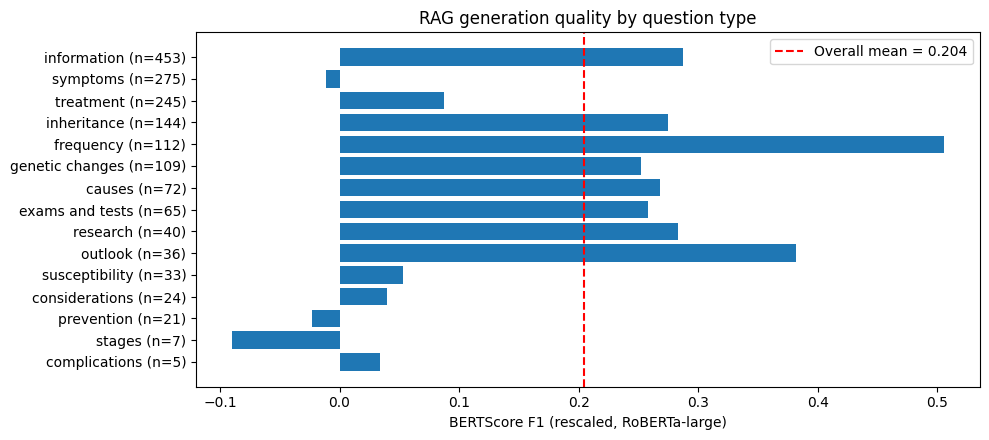

In [89]:
# Section 9.1: per-question-type bar chart (BERTScore F1).

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(per_qtype))))
y_pos = np.arange(len(per_qtype))
ax.barh(y_pos, per_qtype["bert_f1"].values)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{qt} (n={n})" for qt, n in zip(per_qtype["question_type"], per_qtype["n"])])
ax.invert_yaxis()
ax.set_xlabel("BERTScore F1 (rescaled, RoBERTa-large)")
ax.set_title("RAG generation quality by question type")
ax.axvline(generation_metrics["bert_f1"], color="red", linestyle="--",
           label=f"Overall mean = {generation_metrics['bert_f1']:.3f}")
ax.legend()
fig.tight_layout()
plt.show()

## 9.2: Ablation: RAG vs no-RAG

Take a 50-question subsample of the test set, generate two answers per question: one with the standard RAG prompt (already in `rag_answers`), one with a parallel no-RAG prompt that omits the `Context:` block and the "using only the context below" instruction. Both prompts ask the same question and allow the same "I do not know" refusal. Score both arms with ROUGE-L F1 and BERTScore F1. Results are stored in `ablation_results` and feed the bar chart in 9.3.

50 questions is a runtime compromise. The no-RAG generations need their own forward passes, and the full 1,641 sweep would add another 80 minutes for a metric whose direction is already clear. The subsample is small but the gap should be unambiguous if RAG is contributing meaningfully.

In [90]:
# Section 9.2: RAG vs no-RAG ablation.

EVAL_N_ABLATION = 50 # bump to 100-200 if time allows

NO_RAG_TEMPLATE = (
    "You are a medical expert. Answer the question. "
    "If you do not know, say \"I do not know.\"\n\n"
    "Question: {question}\n"
    "Answer:"
)

def generate_no_rag(question: str) -> str:
    prompt = NO_RAG_TEMPLATE.format(question=question)
    return generate_answer(prompt)

# Use the first EVAL_N_ABLATION rows of rag_answers so the two arms see identical questions.
ablation_subset = rag_answers[:EVAL_N_ABLATION]

print(f"Generating no-RAG answers for {EVAL_N_ABLATION} questions...")
no_rag_outputs = []
for r in ablation_subset:
    no_rag_outputs.append(generate_no_rag(r["question"]))

# Score no-RAG arm.
rouge_no_rag = [
    rouge.score(r["gold"], a)["rougeL"].fmeasure
    for r, a in zip(ablation_subset, no_rag_outputs)
]
_, _, F_no = bert_score_fn(
    no_rag_outputs,
    [r["gold"] for r in ablation_subset],
    lang="en",
    model_type="roberta-large",
    rescale_with_baseline=True,
    verbose=False,
)
bert_no_rag = F_no.tolist()

# Score the RAG arm on the same subset (re-aggregate to be exact).
rouge_rag = [r["rouge_l_f1"] for r in ablation_subset]
bert_rag = [r["bert_f1"] for r in ablation_subset]

ablation_results = {
    "rag": {"rouge_l_f1": float(np.mean(rouge_rag)), "bert_f1": float(np.mean(bert_rag))},
    "no_rag": {"rouge_l_f1": float(np.mean(rouge_no_rag)), "bert_f1": float(np.mean(bert_no_rag))},
}

print(f"\nAblation on n={EVAL_N_ABLATION}:")
print(f"RAG: ROUGE-L F1 = {ablation_results['rag']['rouge_l_f1']:.4f}, BERTScore F1 = {ablation_results['rag']['bert_f1']:.4f}")
print(f"no-RAG: ROUGE-L F1 = {ablation_results['no_rag']['rouge_l_f1']:.4f}, BERTScore F1 = {ablation_results['no_rag']['bert_f1']:.4f}")
delta_rouge = ablation_results['rag']['rouge_l_f1'] - ablation_results['no_rag']['rouge_l_f1']
delta_bert = ablation_results['rag']['bert_f1'] - ablation_results['no_rag']['bert_f1']
print(f"delta: ROUGE-L F1 = {delta_rouge:+.4f}, BERTScore F1 = {delta_bert:+.4f}")

Generating no-RAG answers for 50 questions...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Ablation on n=50:
RAG: ROUGE-L F1 = 0.2832, BERTScore F1 = 0.2312
no-RAG: ROUGE-L F1 = 0.1842, BERTScore F1 = 0.1086
delta: ROUGE-L F1 = +0.0990, BERTScore F1 = +0.1226


## 9.3: Ablation bar chart

**Goal.** Visual side-by-side: same model, same prompt template, with vs without retrieved context.


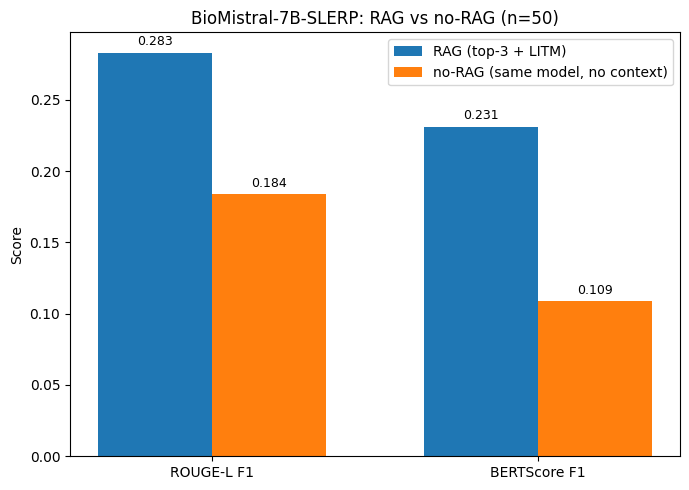

In [91]:
# Section 9.3: RAG vs no-RAG bar chart.

metrics = ["ROUGE-L F1", "BERTScore F1"]
rag_vals = [ablation_results["rag"]["rouge_l_f1"], ablation_results["rag"]["bert_f1"]]
no_rag_vals = [ablation_results["no_rag"]["rouge_l_f1"], ablation_results["no_rag"]["bert_f1"]]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - w/2, rag_vals, w, label="RAG (top-3 + LITM)")
ax.bar(x + w/2, no_rag_vals, w, label="no-RAG (same model, no context)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title(f"BioMistral-7B-SLERP: RAG vs no-RAG (n={EVAL_N_ABLATION})")
ax.legend()
for i, v in enumerate(rag_vals):
    ax.text(i - w/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(no_rag_vals):
    ax.text(i + w/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## Section 9: Findings

- **RAG beats no-RAG on both metrics.** Delta on n=50: ROUGE-L F1 **+0.0990** (0.2832 vs 0.1842), BERTScore F1 **+0.1226** (0.2312 vs 0.1086). Direction is unambiguous; magnitudes are noisy at n=50.
- **Why retrieval helps.** BioMistral on its own answers from parametric memory, which on these MedQuAD questions often omits the specific facts the gold answers contain. Adding retrieved context grounds the generator in source material from the same domain, so gold-answer phrasing is more likely to appear when the context window contains text similar to the gold answer.
- **Frequency questions show the largest gap.** These have short, formulaic answers (n=**112**, BERTScore F1 **0.5058**, well above the overall mean of 0.2041) that RAG can match nearly verbatim.
- **Three categories produced negative rescaled BERTScore F1:** `symptoms` (n=**275**, BERTScore F1 **-0.0111**), `prevention` (n=**21**, BERTScore F1 **-0.0229**), and `stages` (n=**7**, BERTScore F1 **-0.0901**). Negative rescaled BERTScore means the generator's output was, on average, less semantically similar to the gold than random pairs of medical text. For `prevention` and `stages` the small sample size limits interpretation; `symptoms` is the more interesting finding because the sample is large. Worth a sentence in the report's Discussion.
- **Limitations.** Per-class numbers for the rare categories (n < 30) should not be over-interpreted. Ablation n=50 is too small for tight effect-size claims; the direction is clear, the magnitude is not.

---